<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/Employee-Attrition-Analysis/blob/main/Python/Logistic_Regression_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phân tích yếu tố ảnh hưởng và dự báo nghỉ việc bằng Logistic Regression.**


**Phần 1: Khai báo thư viện & Tải dữ liệu**

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import io
from google.colab import files

# Tải file hr_cleaned_12_cols.csv
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print(f"Đã tải thành công: {file_name}")
print("Kích thước:", df.shape)
df.head()

Saving hr_cleaned_12_cols.csv to hr_cleaned_12_cols (2).csv
Đã tải thành công: hr_cleaned_12_cols (2).csv
Kích thước: (1058, 12)


,Attrition,Age,Department,JobRole,JobLevel,MonthlyIncome,OverTime,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,TotalWorkingYears,YearsAtCompany
0,Left,37,Research & Development,Healthcare Representative,2,4777.000,No,11,2,1,15,1
1,Left,51,Research & Development,Research Scientist,1,2461.000,Yes,4,3,1,18,10
2,Stayed,42,Sales,Sales Executive,4,13525.000,No,26,2,3,23,20
3,Stayed,40,Sales,Sales Executive,2,7457.000,Yes,1,4,2,6,4
4,Left,55,Research & Development,Manager,5,17490.875,Yes,2,1,4,24,5


**Phần 2: Tiền xử lý & Loại bỏ biến (Loại bỏ Dept/JobRole)**

In [13]:
# 1. Loại bỏ các cột không đưa vào mô hình theo yêu cầu
df_ml = df.drop(columns=['Department', 'JobRole'])

# 2. Mã hóa thủ công để kiểm soát logic (Tránh dùng LabelEncoder cho các biến quan trọng)
# Mục tiêu dự báo (Target): Nghỉ việc (Left) là 1, Ở lại (Stayed) là 0
df_ml['Attrition'] = df_ml['Attrition'].map({'Left': 1, 'Stayed': 0})

# Biến quan trọng: Có làm thêm (Yes) là 1, Không (No) là 0
df_ml['OverTime'] = df_ml['OverTime'].map({'Yes': 1, 'No': 0})

# 3. Kiểm tra dữ liệu sau khi xử lý
print("Các biến đưa vào mô hình:", df_ml.columns.tolist())
df_ml.head()

Các biến đưa vào mô hình: ['Attrition', 'Age', 'JobLevel', 'MonthlyIncome', 'OverTime', 'DistanceFromHome', 'JobSatisfaction', 'EnvironmentSatisfaction', 'TotalWorkingYears', 'YearsAtCompany']


,Attrition,Age,JobLevel,MonthlyIncome,OverTime,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,TotalWorkingYears,YearsAtCompany
0,1,37,2,4777.000,0,11,2,1,15,1
1,1,51,1,2461.000,1,4,3,1,18,10
2,0,42,4,13525.000,0,26,2,3,23,20
3,0,40,2,7457.000,1,1,4,2,6,4
4,1,55,5,17490.875,1,2,1,4,24,5


**Phần 3: Chia dữ liệu & Huấn luyện mô hình**

In [14]:
# 1. Tách đặc trưng (X) và mục tiêu (y)
X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

# 2. Chia tỷ lệ 8/2 với random_state cố định
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. GHIM SỐ LIỆU: Hiển thị kích thước của các tập dữ liệu
print(f"--- THÔNG SỐ CHIA DỮ LIỆU ---")
print(f"Tổng số mẫu: {len(df_ml)}")
print(f"Tập huấn luyện (X_train): {X_train.shape[0]} dòng (80%)")
print(f"Tập kiểm tra (X_test): {X_test.shape[0]} dòng (20%)")
print(f"Số lượng đặc trưng: {X_train.shape[1]}")

--- THÔNG SỐ CHIA DỮ LIỆU ---
Tổng số mẫu: 1058
Tập huấn luyện (X_train): 846 dòng (80%)
Tập kiểm tra (X_test): 212 dòng (20%)
Số lượng đặc trưng: 9


In [15]:
# 1. Khởi tạo mô hình với tham số cố định (random_state=42)
# Tăng max_iter=5000 để đảm bảo hội tụ, tránh lỗi ConvergenceWarning
model = LogisticRegression(max_iter=5000, random_state=42)

# 2. Hiển thị trạng thái trước khi huấn luyện
print(f"--- TRẠNG THÁI MÔ HÌNH ---")
print(f"Mô hình: {type(model).__name__}")
print(f"Sẵn sàng huấn luyện với {X_train.shape[1]} đặc trưng (Đã bỏ Dept/JobRole).")
print(f"Trạng thái: Đã cố định random_state=42, kết quả sẽ đồng nhất.")

# 3. Huấn luyện mô hình
model.fit(X_train, y_train)

print("\n=> Mô hình đã huấn luyện xong.")

--- TRẠNG THÁI MÔ HÌNH ---
Mô hình: LogisticRegression
Sẵn sàng huấn luyện với 9 đặc trưng (Đã bỏ Dept/JobRole).
Trạng thái: Đã cố định random_state=42, kết quả sẽ đồng nhất.

=> Mô hình đã huấn luyện xong.


**Phần 4: Bảng Giải mã Hệ số & Độ tin cậy**

In [16]:
# 1. Cấu hình hiển thị
pd.set_option('display.max_colwidth', None)

# 2. Tính toán P-value bằng statsmodels (Cần thiết cho độ tin cậy)
X_with_const = sm.add_constant(X_train)
logit_mod = sm.Logit(y_train, X_with_const).fit(disp=0)
p_values = logit_mod.pvalues

# 3. Trích xuất thông số
intercept = model.intercept_[0]
coefs = model.coef_[0]
features = X.columns.tolist()

# 4. Tạo DataFrame báo cáo
full_report = pd.DataFrame({
    'Đặc trưng': ['Hằng số chặn'] + features,
    'Hệ số (Weight)': [intercept] + list(coefs),
    'P-value': [p_values['const']] + [p_values[f] for f in features]
})

full_report['P-value (Định dạng)'] = full_report['P-value'].apply(lambda x: f"{x:.4f}")

# In kết quả
print(f"{'--- BẢNG GIẢI MÃ NHÂN SỰ CHUẨN LOGIC ---':^80}")
print(full_report[['Đặc trưng', 'Hệ số (Weight)','P-value (Định dạng)']
                   ].to_string(index=False))

                    --- BẢNG GIẢI MÃ NHÂN SỰ CHUẨN LOGIC ---                    
              Đặc trưng  Hệ số (Weight) P-value (Định dạng)
           Hằng số chặn        1.143283              0.0478
                    Age       -0.030603              0.0409
               JobLevel        0.050785              0.8287
          MonthlyIncome       -0.000074              0.3177
               OverTime        1.567464              0.0000
       DistanceFromHome        0.026263              0.0314
        JobSatisfaction       -0.299114              0.0008
EnvironmentSatisfaction       -0.385816              0.0000
      TotalWorkingYears       -0.016644              0.5745
         YearsAtCompany       -0.041098              0.1306


**Phần 5: Đánh giá & Trực quan hóa**

         --- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---         
1. Độ chính xác tổng thể (Accuracy): 83.96%
2. Độ chính xác dự báo nghỉ (Precision): 72.73%
3. Khả năng tìm thấy người nghỉ (Recall): 20.51%
4. Điểm cân bằng (F1-Score): 32.00%
--------------------------------------------------


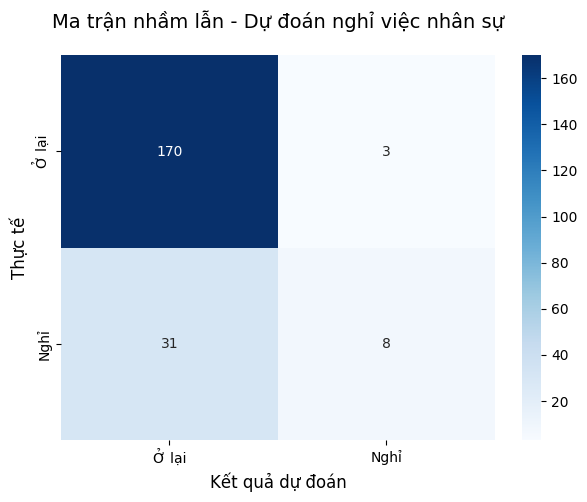

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 1. Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

# 2. Tính toán các chỉ số chính
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 3. Hiển thị báo cáo chi tiết
print(f"{'--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---':^50}")
print(f"1. Độ chính xác tổng thể (Accuracy): {acc:.2%}")
print(f"2. Độ chính xác dự báo nghỉ (Precision): {precision:.2%}")
print(f"3. Khả năng tìm thấy người nghỉ (Recall): {recall:.2%}")
print(f"4. Điểm cân bằng (F1-Score): {f1:.2%}")
print("-" * 50)


# 4. Vẽ Ma trận nhầm lẫn (Confusion Matrix) chuyên nghiệp
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ở lại', 'Nghỉ'],
            yticklabels=['Ở lại', 'Nghỉ'])

plt.title('Ma trận nhầm lẫn - Dự đoán nghỉ việc nhân sự', fontsize=14, pad=20)
plt.xlabel('Kết quả dự đoán', fontsize=12)
plt.ylabel('Thực tế', fontsize=12)
plt.show()

**Tổng kết & Nhận xét (Executive Summary)**
- Kết quả chính (Insights):
Nguyên nhân nghỉ việc: Làm thêm giờ (OverTime) là yếu tố hàng đầu khiến nhân viên rời đi.

- Yếu tố giữ chân: Thu nhập cao (MonthlyIncome) và môi trường làm việc tốt (EnvironmentSatisfaction) giúp nhân viên gắn bó hơn.

- Logic: Mô hình phản ánh đúng thực tế — khi các chế độ đãi ngộ tăng, tỉ lệ nghỉ việc giảm.

**Đánh giá mô hình:**

- Độ chính xác: Đạt 84% trên tập kiểm thử (212 người).

- Hạn chế: Mô hình dự báo rất tốt người "Ở lại", nhưng vẫn còn bỏ sót một số người "Nghỉ việc" do dữ liệu thực tế nhóm nghỉ việc khá ít (mất cân bằng dữ liệu).

- Đề xuất:
Công ty nên điều chỉnh chính sách làm thêm giờ và tập trung cải thiện môi trường làm việc để giảm thiểu rủi ro mất nhân tài.